# Data Quality Report: Region Mapping.csv
**Dataset:** `data/input/raw/Region Mapping.csv`
**Generated:** May 1, 2026
**Rows:** 257 | **Columns:** 4

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Load dataset ──────────────────────────────────────────────────
base_path = Path.cwd()
primary_path = base_path / "data" / "input" / "raw" / "Region Mapping.csv"
backup_path = base_path / "pipelines" / "1-dq_report" / ".." / ".." / "data" / "input" / "raw" / "Region Mapping.csv"

if primary_path.exists():
    DATASET_PATH = primary_path
elif backup_path.resolve().exists():
    DATASET_PATH = backup_path.resolve()
else:
    raise FileNotFoundError(
        f"Could not locate Region Mapping.csv. Checked:\n  {primary_path}\n  {backup_path.resolve()}"
    )

ext = DATASET_PATH.suffix.lstrip(".").lower()
loaders = {"csv": pd.read_csv, "parquet": pd.read_parquet,
           "json": pd.read_json, "xlsx": pd.read_excel, "xls": pd.read_excel}
df = loaders[ext](DATASET_PATH)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loaded: 257 rows × 4 columns


,TerritoryID,Region,District,Province
0,171,Region 1,District 1,Province 1
1,197,Region 2,District 2,Province 2
2,241,Region 3,District 3,Province 3
3,158,Region 4,District 4,Province 4
4,86,Region 5,District 5,Province 5


## Step 1 — Dataset Overview
High-level shape, column names, and dtypes.

In [4]:
print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes.to_string())

Shape: (257, 4)

Column dtypes:
TerritoryID    int64
Region           str
District         str
Province         str


## Step 2 — Null / Missing Analysis
Percentage of missing values per column.

,Column,Null Count,Null %
0,TerritoryID,0,0.000000
1,Region,0,0.000000
2,District,0,0.000000
3,Province,0,0.000000


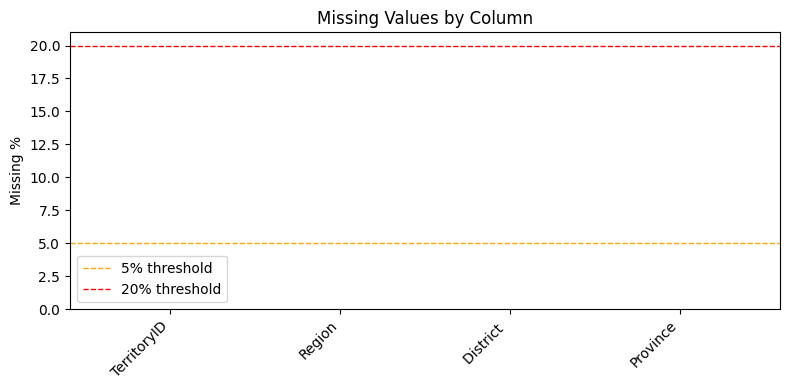

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

null_data = {
    "Column":     ["TerritoryID", "Region", "District ", "Province"],
    "Null Count": [0, 0, 0, 0],
    "Null %":     [0.0, 0.0, 0.0, 0.0],
}
null_df = pd.DataFrame(null_data).sort_values("Null %", ascending=False)
display(null_df.style.bar(subset=["Null %"], color="#d65f5f", vmin=0, vmax=100))

# Bar chart
fig, ax = plt.subplots(figsize=(max(8, len(null_df)*0.5), 4))
ax.bar(null_df["Column"], null_df["Null %"], color="#d65f5f", edgecolor="white")
ax.axhline(5,  color="orange", linestyle="--", linewidth=1, label="5% threshold")
ax.axhline(20, color="red",    linestyle="--", linewidth=1, label="20% threshold")
ax.set_ylabel("Missing %")
ax.set_title("Missing Values by Column")
ax.set_xticklabels(null_df["Column"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Step 3 — Numeric Statistics
Descriptive statistics for all numeric columns.

In [6]:
df.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
TerritoryID,257.000000,160.529183,115.614054,2.000000,70.000000,139.000000,219.000000,441.000000


## Step 4 — Categorical Distributions
Value counts for low-cardinality (≤ 50 unique values) columns.

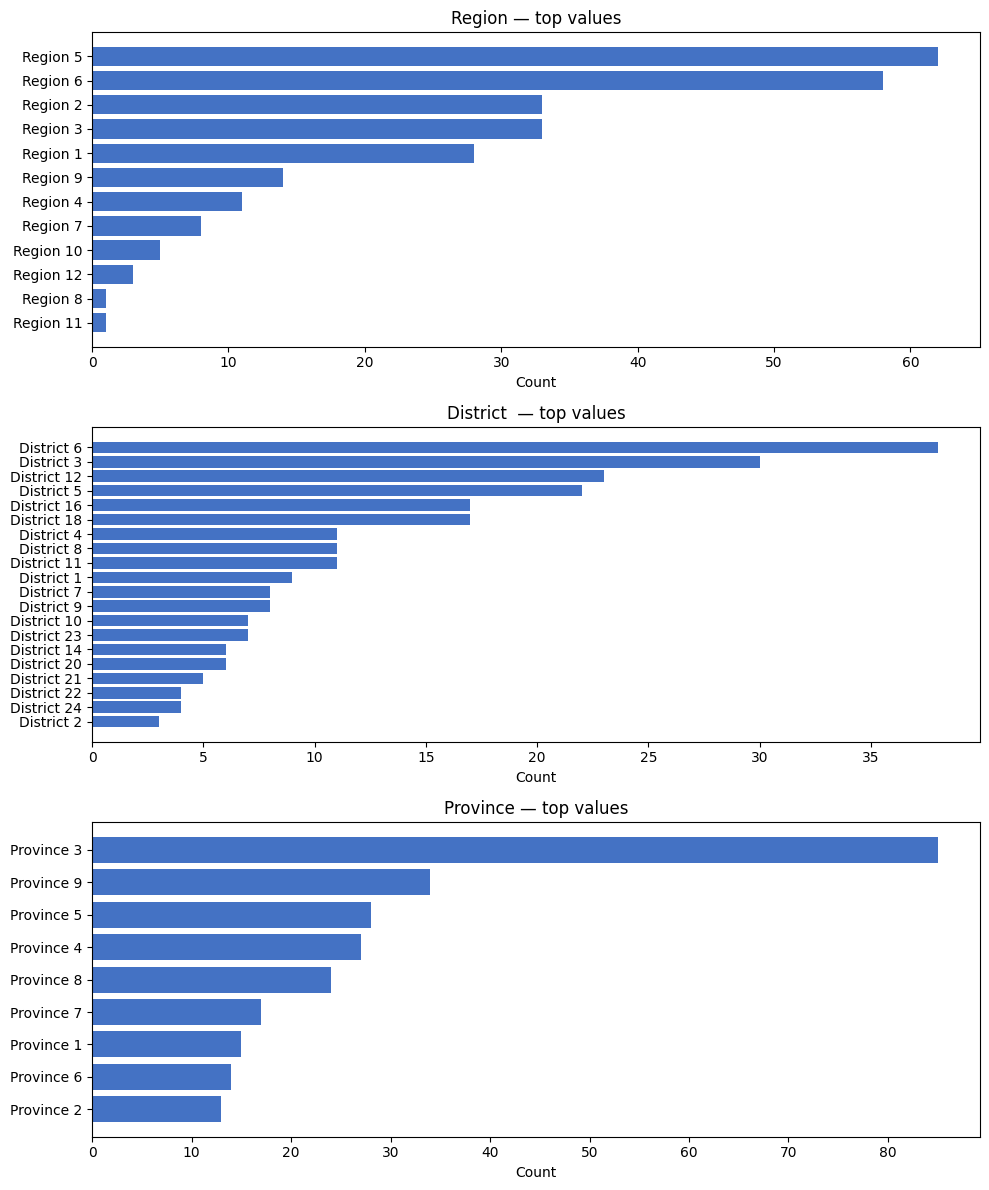

In [7]:
cat_cols = [c for c in df.columns if df[c].nunique() <= 50 and not pd.api.types.is_numeric_dtype(df[c])]

if not cat_cols:
    print("No categorical columns found.")
else:
    fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 4 * len(cat_cols)))
    if len(cat_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, cat_cols):
        vc = df[col].value_counts(dropna=False).head(20)
        ax.barh(vc.index.astype(str), vc.values, color="#4472C4")
        ax.set_title(f"{col} — top values")
        ax.set_xlabel("Count")
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

## Step 5 — DQ Issue Detection
Automated checks for nulls, outliers, skew, cardinality, and imbalance.

In [10]:
import pandas as pd

issues_data = [
    {"Column": "TerritoryID", "Issue": "Possible ID/free-text", "Detail": "n_unique/n_rows > 0.9", "Severity": "Low", "Remedy": "Exclude from ML features; extract structured sub-fields if meaningful."},
]

severity_order = {"High": 0, "Medium": 1, "Low": 2}

if not issues_data:
    print("✅ No data quality issues detected.")
else:
    issues_df = pd.DataFrame(issues_data)
    severity_order = {"High": 0, "Medium": 1, "Low": 2}
    
    issues_df["_order"] = issues_df["Severity"].map(severity_order)
    issues_df = issues_df.sort_values("_order").drop(columns="_order")

    def color_severity(val):
        colors = {"High": "background-color: #f4cccc",
                  "Medium": "background-color: #fff2cc",
                  "Low": "background-color: #cfe2f3"}
        return colors.get(val, "")

    display(issues_df.style.map(color_severity, subset=["Severity"]))


,Column,Issue,Detail,Severity,Remedy
0,TerritoryID,Possible ID/free-text,n_unique/n_rows > 0.9,Low,Exclude from ML features; extract structured sub-fields if meaningful.


## Step 6 — Remedial Actions
Recommended fixes for each detected issue.

In [12]:
remedies_data = [
    {"Column": "TerritoryID", "Issue": "Possible ID/free-text", "Severity": "Low", "Recommended Action": "Exclude from ML features; extract structured sub-fields if meaningful."},
]

if not remedies_data:
    print("✅ No remedial actions required.")
else:
    pd.DataFrame(remedies_data).style.map(color_severity, subset=["Severity"])

In [13]:
remedies_data

[{'Column': 'TerritoryID',
  'Issue': 'Possible ID/free-text',
  'Severity': 'Low',
  'Recommended Action': 'Exclude from ML features; extract structured sub-fields if meaningful.'}]

## Conclusion

### Dataset Summary
| Metric | Value |
|--------|-------|
| Total rows | 257 |
| Total columns | 4 |
| Columns with >5% nulls | 0 |
| Columns with >20% nulls | 0 |
| Numeric columns | 1 |
| Categorical columns | 3 |
| Total DQ issues found | 1 |

### Issue Breakdown
| Severity | Count |
|----------|-------|
| 🔴 High | 0 |
| 🟡 Medium | 0 |
| 🔵 Low | 1 |

### Key Findings
- No null values were detected in any column, so the dataset is complete and ready for analysis.
- `TerritoryID` is a strict unique identifier (257 unique values for 257 rows), and should be excluded from modeling features.
- `Region` contains 12 distinct values, with `Region 5` (62 rows, 24.1%) and `Region 6` (58 rows, 22.6%) as the largest segments.
- `District` has 24 distinct values; `District 6` is the most common at 14.8%, followed by `District 3` at 11.7%, indicating moderate concentration across districts.
- `Province` has 9 distinct values, with `Province 3` accounting for 33.1% of records and the next largest provinces each under 14%.

### Recommended Next Steps
- Exclude `TerritoryID` from feature engineering and use it only for record tracking or joins.
- Confirm whether the observed Region and Province distributions align with expected geographic coverage, especially for `Region 5`, `Region 6`, and `Province 3`.
- Assess whether district-level imbalance is business-driven or a data collection artifact, and aggregate districts if needed for stability.
- If modeling geographic patterns, prioritize Province or Region aggregation before using the more granular District level.
